### Objectives
- Create MCP serves in STIO and HTTP trasnprot using FastMCP
- Regiser custom tools, resources, and tprmpt s to an MCP server
- Test MCP serves with clietn connections and manual tool calling
- Create a multi server client and ReAct agent

### MCP server
- MCP server is like a remote library
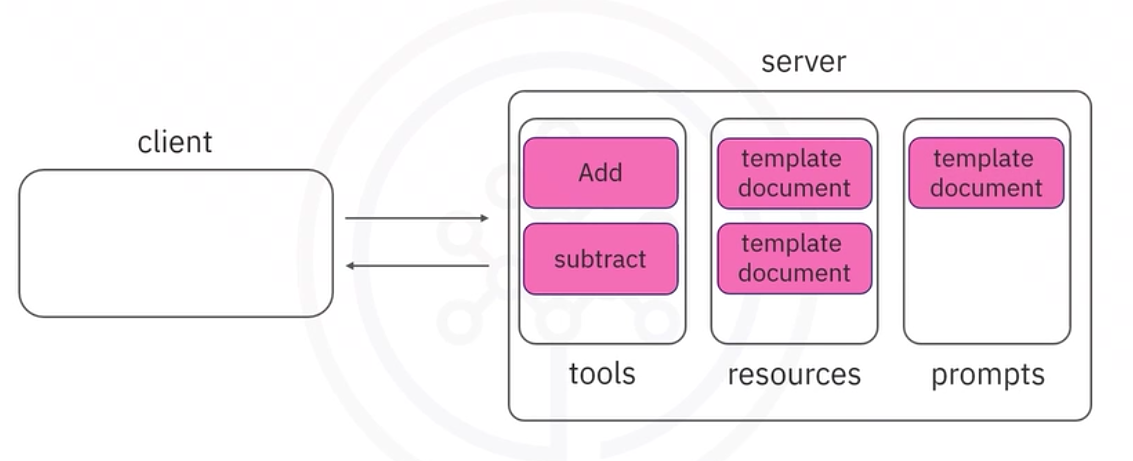

### MCP sever object
- create FastMCP sever object
```python
from fastmcp import FastMCP
mcp = FastMCP(
    name="CalculatorMCPSever",
    instructions="""
    This sever provides data analysis tools.
    Call get_average() to analyze numerical data.
    """
)
```
- `name` identifies the MCP sever
- `instructions` natural language docuemnation for the llm

### MCP tools
```python
@mcp.tool
def add(a:int, b:int) -> int:
    "Add two integers together"
    return a + b

@mcp.tool
def subtract(a: int, b: int) -> int:
    "subtract one integer from another"
    return a-b
```

### Resources
- filing cabinets that AI system can access
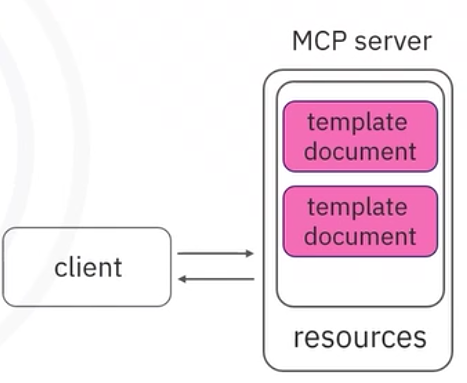
```python
@mcp.resource("file:///endpoint/{name}")
def return_template_document(name: str) -> str:
    """Read a document by name"""
    return f"Document contents of {name}"
```
- name: path parameter, that is an input to the function
- the resources retuns a file

```python
@mcp.resource("file//endpoint/{name}")

def read_document(name:str) -> str:
    "Read a document by name from the path directory"
    try:
        with open(f"path/{name}", "r") as f:
            return f.read()
        except FileNotFoundError:
            return f"Document '{name}' not found in path directory"
        except Exception as e:
            return f"Error reading document: {str(e)}"
```

- prompts are reusable template for common tasks
- save them once, and AI can call them by name
    - example code review prompt


### Transport
#### In-Memory transport
- to test the funtions
- the sever is running on the same process

```python 
from fastmcp import Client
client = Client(mcp)

# call tool
asycn with client:
    result = await client.call_tool("add", {
        "a": a, "b": b
    })

print(result)

```
- the mcp is the FastMCP sever we have defined inline

#### Test MCP resource
- use a function that call the mcp function
```python
async def call_resource(name):
    async with client:
        result = await client.read_resounce(f"file:///endpoint/{name}")

    return result

response = await call_response("README.txt")
```

### HTTP MCP Server
- Create the HTTP MCP sever

```python
PORT = 8000
mcp.run_http_async(port=PORT)
```
- server can be accesssed by url: "http://127.0.0.1:8000/mcp"
- HTTP MCP sever can be located anywhere
    - just need access to the URL

#### Create HTTP transport
```python
from fastmcp.client.transports import StreamableHtttpTrasport

trasport_http = StreamableHttpTrasport(
    url = f"http://127.0.0.1:{PORT}/mcp"
)
# create client
http_client = Client(trasport_http)

# to test MCP client
async def test_client_http(client: Client, a:int, b:int) -> int:
    async with client:
        result = await client.call_tool("add", {"a": a, "b":b})
    return result

response = await test_client(http_client, 4, 5)
```

### MCP HTTP-powered agent
- the tool has an agent (inside the tool)
```python
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI

llm = "openai:gpt-5-nano"

from langchain_mcp_adpters.tools import load_mcp_tools
from mcp import ClientSession
from mcp.client.stramable_http import stramablehttp_client

async with stramablehttp_client(f"http://127.0.0.1:{PORT}/mcp") as (read, write, _sid):
    async with ClientSession(read, write) as session:
        await session.initialize()

        tools = await load_mcp_tools(session)
        agent = create_eract_agent(model=llm, tools=tools,)
        agent_response = await agent.ainvoke(
            {
                "messages": "Use the add tool to add 2 and 1 and let me know if you used a tool."
            }
        )

agent = create_reach_agent(model=llm, tools=tools)
agent_response = await agent. ainvoke({
    "messages": "Use the add tool to add 1 and 1 and i and let me know if you used a tool."
})
```

### STDIO MCP Server
- runs on your own system
- This is done via python file "stdio_server.py"
- 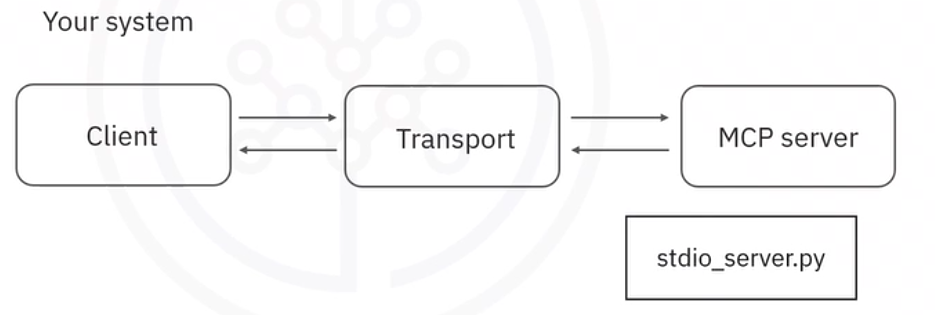
- file
- 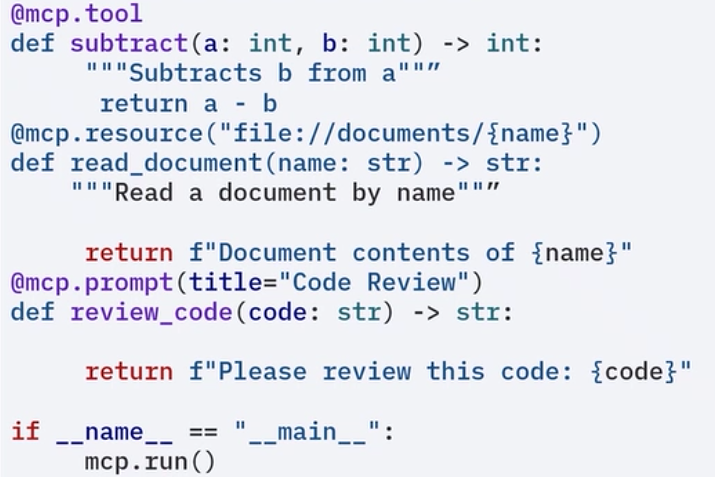



### Summary
- The trasport is how MCP server communicate 
- Create an MCP tool is exactly like creating a tool in LangChain
- Resources are like filing cabinet that AI system can access
- Promts are resuable tempalte for common tasks
- In-Memory Trasport is a fast way to test your MCP server
- With the HTTP trasport, the MCP sever can be located anywhere, as long as you have ccess to the URL
- with the STIO trasport, the server runs on your own system
- Using STDIO trasport with an LLM is identical to using HTTP, except for the transport configuration
- You can connect to multiple MCP servers using 'MultiServerMCPClient'

## Enhanced MCP Sever
### Objetives
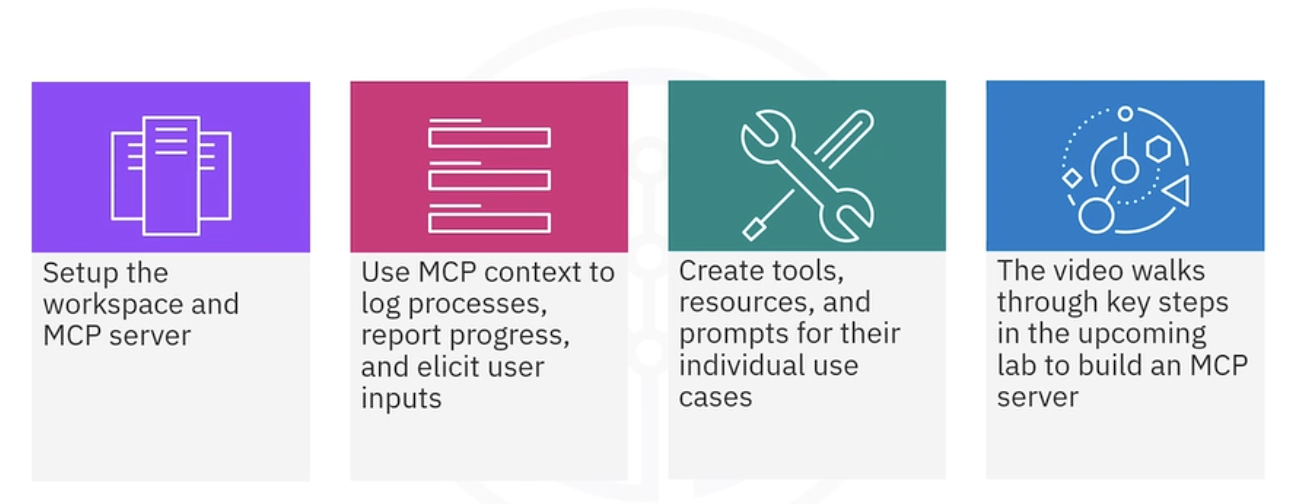

### MCP server setup
- open ´server.py´ file

```python
from pathlib import Path
from datetime import datetime
from pydantic import BaseModel
import time
from fastmcp import FastMCP, Context

# Project root directory
BASE_DIR = Path.cwd()

class DocumentGeneratorSchema(BaseModel):
    """
    Pydantic model for documentation filename schema.
    Used in elicitation to capture user intput for documenation file names.
    Attribtues:
        file_path: Path of the file we want to generate document on
        name: Th ename of the documenation file to create
    """
    file_path: str
    name: str
    # FastMCP sever instance for handling MCP protocol opeations
    mcp = FastMCP("File Operations MCP Server")

def get_path(relative_path: str) -> Path:
    """
    Convert relative path to absolute path within project directory.
    Ensures the path is within BASE_DIR for security. Resolves the path
    and validates it's relative to the base directory

    Args:
        relative_path: Relative path string to convert
    Returns:
        Absolute Path object within BASE_DIR
    Raises:
        ValueError: If path is outside BASE_DIR
    """
    rel = Path(relative_path).resolve().relative_to(BASE_DIR)
    return rel
```
### MCP Sever - Context
- MCP sever primites
    - tools
    - Resorces
    - prompts
- may need to acess to the undelying MCP session or adanced MCP capabilites
- `Context` Object form `FastMCP` library provese a clien interface for accessing these features and capabilites
- The functionalities
    - Logging: Logs info & error messages
    - Progress Reporting: Disply progress of continues tasks
    - User Elicitation: Structured inputs from the user
- 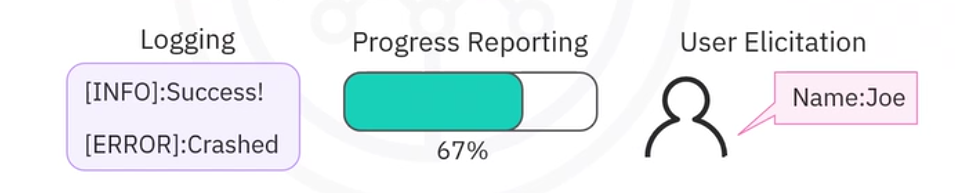

```python
@mcp.tool()
async def write_file(file_path:str, content: str, ctx: Context) -> str:
    try:
        path = get_path(file_path)
        # create parent directories if they don't exist
        path.parent.mkdir(parents=True, exist_ok=True)
        total = len(content)
        chunk_size = max(total//10, 1)
        # writ econtent with UTF-8 encoding with progress reporting
        writeen = 0
        with open(path, "w", encoding="utf-8") as f:
            for i in range(0, total, chunk_size):
                f.write(content[i:i+chunk_size])
                written = min(i+chunk_size, total)
                await ctx.report_progress(progress=written, total=total, messages=f"Writing prograss:{written}/{total}")
                time.slee(0.05)
        # also log error messages using context
        await ctx.report_progress(progress=total, total=total, message="Write complete")
        await ctx.info(f"File wirteen successfully to: {file_path}")
        return f"File written successfully to: {file_path}"
    excpet Exception as e:
        # context is used to log an error message
        await ctx.error(f"Error creating file {str(e)}")
        rise
```
- the second tool delete files

```python
@mcp.tool()
async def delete_file(file_path: str, ctx: Context) -> str:
    try:
        path = get_path(file_path)
        # Check if path exists and is a file
        if path.is_file():
            path.unlink()
            await cts.info(f"Successfully delted file {file_path}")
            return f"SUccessfully deleted file{file_path}"
        elif path.is_dir():
            await ctx.warning(f"Error {file_path} is a directory, not a file")
            return f"Error: {file_path} is a directory, not a file"
        else:
            await ctx.warning(f"File not found: {file_path}")
            return f"file not found: {file_path}"
    except Exception as e:
        awiat ctx.error(f"Error deleting file. {str(e)}")
        return f"Error deleting file: {str(e)"}
```

### MCP server: Resources
- Resoruces are used to fetch static or dynamic inforamton form databases, remote repositories or local files
- If the fetch process is the main puropse of the resoruce, you are better off using a tool
    - Example: fetching from remote repositories that require special configuration - make a tool with an input for the infrormation you want
- Uniform Resource Idnetifier (URI) provides structured resouce identification and parameterization for MCP resouces (Example: resouce templates)
- Static portion of URI could be anything and is chosen by MCP server developer (dir:// of docs://)
- REsouces are best used for passive data access of redily available information
- Tools are best used for active operations (Exmaple call to a database)
- Resouces that have parameterized URIs are knowas as resouce templates
- They serve the same functions as normal resouces but function a bit differently (dynamic URI)

```python
# to fetch a file that is relative to the current directory
@mcp.resouces("file:///{file_name}")
async def read_file_resouce(file_name: str) -> dict:
    try:
        path = get_path(file_name)
        # validate path exists and is a file
        if not path.exists() or not path.is-file():
            return {"error": f"Error: {file_name} is not a valid file"}
        # read and return file content
        return {"file_content": path.read_text(encoding="utf-8")}
    except Exception as e:
        return {"error": f"Error reading file: {str(e)}"}
```
- here we have used three "/"
    - `@mcp.resouces("file:///{file_name}")`
- this is because `file://` is a resver keyword

- another resouce to list all the files and directories in the directory
```python
@mcp.resouce("dir://.")
async def list_files_resouce() -> dict:
    try:
        path = get_path(".") # "." is the current directory
        if not path.exists() r not path.is_dir():
            return {"error": f"{path} is not a valid directory"}

        items = []
        for items in path.iterdir():
            stat = item.stat()
            items.append({
                "name": item.name,
                "path": str(item.relative_to(BASE_DIR)),
                "type": "directory" if item.is_dir() else "file",
                "size": stat.st_size,
                "modified": datetime.fromtimestatmp(stat.st_mtime).isoformat(),
                "created": datetime.fromtimestatmp(stat.st_ctime).isoformat()
            })
            return {
                "items": items
            }
    except Exception as e:
        return {"error": f"Error listing files: {e}"}
```
### MCP Server - Prompts
- prompts are structured tempates that reutrn as prompt message with the given paramter filled out
- Desigened to be user controled: users can choose a prompt based on their situtation and fill out paramter accordingly
- Example: a prompt to perform code reveiw

```python
@mcp.prompt()
async def code_review(file_path: str, ctx: Context) -> str:
    try:
        path = get_path(file_path)

        # Validate file exists
        if not path.exists() or not path.is_file():
            error_msg = f"Error: {file_path} is not a valid file"
            await ctx.warning(error_msg)
            raise FileNotFoundError(error_msg)
        
        # Read code and detect language form extension
        current_code = path.read_text(encoding="utf-8".strip())
        langugae = path.suffix.lower()

        # Geneare structured prompt for code review
        prompt = f"""You are an expert code editor. Review the following code quality.
        File: {file_path}
        langugage (file suffix): {language or "unknown"}

        Current code:
        '''
        {current_code}
        '''
        Provide a comprehensive evaluation of the code:
        """.strip()

        await ctx.info("Successfully returned prompt")
        return prompt
    except Exception as e:
        await ctx.error(f"Error preparing code review prompt: {e}")
        raise
```

### MCP server - User elicitation
- User eliciation uses MCP COntext to allow server to request structured inputs from users during prompt building or tool execution
- Requires a special handling function in the client
- Used in a wide range of secenarios:
    - Missing parameters: Gen unkown information that is required
    - Clarification requests: get user confirmation for ambiguous situations
    - Prograssive desclosure: collect information gradually

```python
@mcp.prompt()
async def documenation_generation(ctx: Context) -> str:
    try:
        # Elicit documentation filename form user via client
        result = await ctx.elicit(
            message = "Please provide the subject file name and the documenation file name", response_type=DocumentGeneratorSchema
        )
        file_path = result.data.file_path
        path = get_path(file_path)

        # validate file exists
        if not path.exists() or not path.is_file():
            error_msg = f"Error: {file_path} is not a valid file"
            await cts.warning(error_msg)
            raise FileNotFoundError(error_msg)
        
        # Read code and detect language from extention
        code = path.read_text(endoding='utf-8').strip()
        language = path.suffix.lower()

        doc_name = result.data.name

        # Geneare structured prompt for code review
        prompt = f"""You are an expert code editor. Review the following code quality.
        File: {file_path}
        langugage (file suffix): {language or "unknown"}

        Current code:
        '''
        {current_code}
        '''
        Use MCP tools available to you to create seperate documenation file:
        - **CRITICAL DETAIL: Name that seprate docuemtn EXACTLY: {doc_name}**
        - Add the .md suffix yourself if the name doesn't include it already
        """.strip()

        await ctx.info("Successfully return prompt")
        return prompt

    except Exception as e:
        await ctx.error(f"Error generating code documentation prompt: {e}")
        raise
```

### MCP sever - Entry point
- need to crate an entry point
- Start the MCP server when the script is run

```python
if __name__ == "__main__":
    print("Starting File Opeation Sever...")
    mcp.run()
```
- this ensure that the sever runs and listents for MCP cliet connection via standard input/output (STDIO)

### Summary
- MCP is a universal protocol that lets LLMs inteact with their environment
- MCP provides a standard structure for extending LLM capabilites through tools, resouces, and prompts
- Tools let models take action, uchs as creating or deleting files
- Resources give models controlled access to data, such as reading files or listing directores
- Prompts define reusable workflows, guiding the model through structred tasks
- The Context system adds logging, progress updates, and user input elicitation for richer interaction
- MCP severs expose these capabilites and MCP clients connect and coordinate them with an LLM